# ECE 8803-AI4 · Lecture 1 — Fault Detection and Classification

### Companion notebook: every figure in the lecture, reproduced from scratch

This notebook rebuilds the whole of Lecture 1: the synthetic tool data, the
healthy population, the eigentrace decomposition, the two detectors, and the
alignment step that repairs them. Nothing is imported from the slide-building
code — the data generator and every computation are written out here, so you
can change any of it and watch the answers move.

**What you need:** `numpy` and `matplotlib`. Nothing else.

**How to use it:** run the cells in order. The section numbers match the
lecture, and the slide numbers are given in each heading.

---

### Contents

| Section | Slides | What it does |
|---|---|---|
| 1 | 3–5 | The recipe trace and its five phases |
| 2 | 6–7 | The problem statement, and a fault that hides |
| 3 | 8–10 | The dataset: 100 healthy runs |
| 4 | 11–12 | The five knobs, and where each one shows up |
| 5 | 13 | Six fault types |
| 6 | 14–16 | A run as a vector; the mean; the deviations |
| 7 | 17–19 | PCA: eigentraces, coefficients, rebuilds |
| 8 | 20–23 | What each eigentrace means, and which knobs PCA recovered |
| 9 | 24 | How many numbers a run needs |
| 10 | 25–27 | Two detectors, and why both fail |
| 11 | 28–30 | Landmark alignment |
| 12 | 31–36 | Everything again, after alignment |
| 13 | 37 | Summary and exercises |

In [1]:
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams.update({
    "figure.figsize": (10.5, 3.4),
    "figure.dpi": 110,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.titlesize": 11,
    "font.size": 10,
})

# Georgia Tech palette, so the figures here match the slides.
NAVY, TEAL, GOLD, RED, GRAY = "#003057", "#008C95", "#A87900", "#A4343A", "#54585A"
FILL = "#CFE6E8"

np.set_printoptions(precision=3, suppress=True)

---
## 1 · The recipe trace  <span style="color:#888">(slides 3–5)</span>

A single recipe step on a real tool logs dozens of channels: chamber
pressure, RF forward and reflected power, gas flows, substrate temperature,
endpoint intensity. Each one is a time series sampled a few thousand times
per run.

We model **one** channel, because everything in these two lectures generalises
channel by channel. The nominal shape — the *golden trace* — is what the
recipe asks the tool to do:

1. **idle** at the base level,
2. **ramp up** to setpoint,
3. **overshoot and settle** (the control loop rings),
4. **plateau** with a small ripple and a slow drift,
5. **ramp down** back to idle.

The constants below are the recipe. They never change from run to run — they
are the deterministic backbone that every run shares.

In [2]:
N_TICKS = 2000            # samples per run
BASELINE = 20.0           # idle level
PLATEAU = 250.0           # process setpoint
SPAN = PLATEAU - BASELINE # 230 units of process excursion

T_RAMP_UP_START = 250.0   # tick where the ramp begins
RAMP_UP_DUR = 90.0        # ticks to reach setpoint
T_RAMP_DN_START = 1600.0  # tick where the ramp-down begins
RAMP_DN_DUR = 130.0       # ticks back to idle

OVERSHOOT_FRAC = 0.06     # peak overshoot, as a fraction of SPAN
OVERSHOOT_TAU = 55.0      # settling time constant, ticks
OVERSHOOT_PERIOD = 130.0  # ringing period, ticks

RIPPLE_AMP = 0.9          # plateau ripple amplitude, units
RIPPLE_PERIOD = 47.0      # plateau ripple period, ticks
DRIFT_TOTAL = 1.6         # total drift across the plateau, units


def smoothstep(x):
    """A C1-continuous 0 -> 1 transition on [0, 1]."""
    x = np.clip(x, 0.0, 1.0)
    return x * x * (3.0 - 2.0 * x)


def golden_signal(t, overshoot_frac=OVERSHOOT_FRAC, ripple_amp=RIPPLE_AMP,
                  ripple_period=RIPPLE_PERIOD, ripple_phase=0.0,
                  drift_total=DRIFT_TOTAL, ramp_up_dur=RAMP_UP_DUR):
    """The noise-free recipe trace, evaluated at (possibly fractional) ticks.

    Defined on continuous time, so a per-run time shift is just an evaluation
    at t + shift. No resampling artefacts.
    """
    t = np.asarray(t, dtype=float)

    up = smoothstep((t - T_RAMP_UP_START) / ramp_up_dur)
    dn = smoothstep((t - T_RAMP_DN_START) / RAMP_DN_DUR)
    env = up * (1.0 - dn)                      # 0 idle, 1 plateau, 0 after
    y = BASELINE + SPAN * env

    # overshoot and damped ringing, starting when the ramp completes
    t_os = t - (T_RAMP_UP_START + ramp_up_dur)
    ring = (overshoot_frac * SPAN
            * np.exp(-np.maximum(t_os, 0.0) / OVERSHOOT_TAU)
            * np.sin(2.0 * np.pi * np.maximum(t_os, 0.0) / OVERSHOOT_PERIOD))
    y += np.where(t_os > 0.0, ring, 0.0) * (1.0 - dn)

    # plateau ripple (control-loop limit cycle) and slow drift
    y += env * ripple_amp * np.sin(2.0 * np.pi * t / ripple_period + ripple_phase)
    plateau_len = T_RAMP_DN_START - (T_RAMP_UP_START + ramp_up_dur)
    y += env * drift_total * np.clip(t_os / plateau_len, 0.0, 1.0)
    return y


t = np.arange(N_TICKS, dtype=float)
golden = golden_signal(t)
print(f"golden trace: {golden.shape[0]} samples, "
      f"idle {golden[:200].mean():.1f}, plateau {golden[800:1500].mean():.1f}")

golden trace: 2000 samples, idle 20.0, plateau 251.0


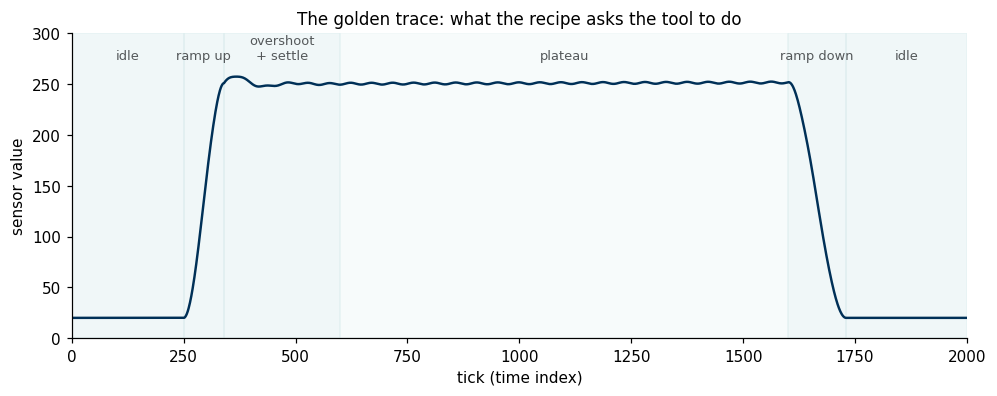

In [3]:
fig, ax = plt.subplots(figsize=(10.5, 3.6))
ax.plot(t, golden, color=NAVY, lw=1.6)

phases = [(0, 250, "idle"), (250, 340, "ramp up"), (340, 600, "overshoot\n+ settle"),
          (600, 1600, "plateau"), (1600, 1730, "ramp down"), (1730, 2000, "idle")]
for x0, x1, name in phases:
    ax.axvspan(x0, x1, color=FILL, alpha=0.30 if name != "plateau" else 0.15)
    ax.text((x0 + x1) / 2, 272, name, ha="center", va="bottom", fontsize=8.5,
            color=GRAY, linespacing=1.2)

ax.set_ylim(0, 300)
ax.set_xlim(0, N_TICKS)
ax.set_xlabel("tick (time index)")
ax.set_ylabel("sensor value")
ax.set_title("The golden trace: what the recipe asks the tool to do")
plt.show()

---
## 2 · The problem statement, and a fault that hides  <span style="color:#888">(slides 6–7)</span>

**The problem.** A run finishes. You have its trace, and a population of runs
that were known to be good. Decide, before the wafers move on, whether this
run was normal.

Two things make it hard.

*No two healthy runs are identical.* The tool starts a few ticks early or
late, the sensor gain drifts a fraction of a percent, the zero point moves.
None of that is a fault, and all of it changes the numbers.

*A fault does not have to break the shape.* Below is a run whose plateau sits
4.5 % of span off target — a mis-calibrated setpoint, a scrap condition — next
to a healthy run. Look at the full trace and they are the same picture. The
defect is 10 units on a 230-unit excursion.

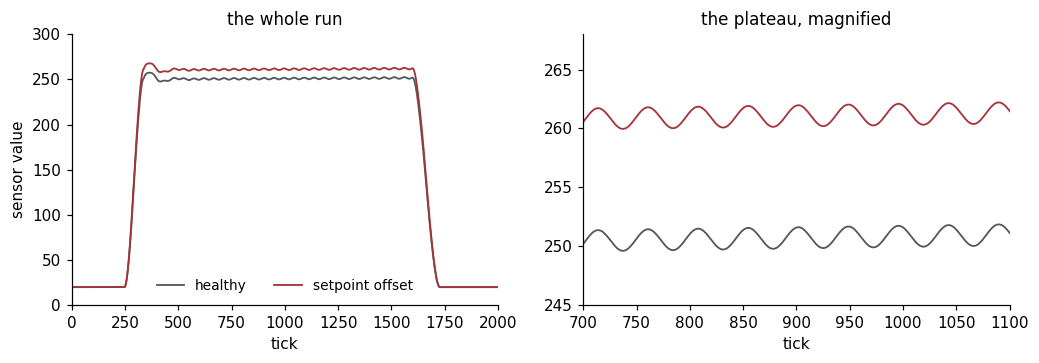

largest gap between the two traces: 10.4 units
as a fraction of the process span : 4.5%


In [4]:
# a healthy-looking run and the same run with a setpoint offset
demo = golden_signal(t + 3.0)                      # a run that starts 3 ticks late
plateau_env = (smoothstep((t - T_RAMP_UP_START) / RAMP_UP_DUR)
               * (1.0 - smoothstep((t - T_RAMP_DN_START) / RAMP_DN_DUR)))
faulty = demo + plateau_env * 0.045 * SPAN         # +4.5 % of span on the plateau

fig, axes = plt.subplots(1, 2, figsize=(11.0, 3.2))
for ax, (x0, x1, title) in zip(axes, [(0, 2000, "the whole run"),
                                      (700, 1100, "the plateau, magnified")]):
    ax.plot(t, demo, color=GRAY, lw=1.2, label="healthy")
    ax.plot(t, faulty, color=RED, lw=1.2, label="setpoint offset")
    ax.set_xlim(x0, x1)
    ax.set_title(title)
    ax.set_xlabel("tick")
axes[0].set_ylim(0, 300)
axes[0].set_ylabel("sensor value")
axes[1].set_ylim(245, 268)
axes[0].legend(frameon=False, loc="lower center", ncol=2, fontsize=9)
plt.show()

print(f"largest gap between the two traces: {np.abs(faulty - demo).max():.1f} units")
print(f"as a fraction of the process span : {np.abs(faulty - demo).max() / SPAN:.1%}")

The point of the lecture is that eyeballing full traces is not a detector.
We need a representation in which "4.5 % of span on the plateau" is a large
number and "started three ticks late" is a small one.

---
## 3 · The dataset  <span style="color:#888">(slides 8–10)</span>

Every number in both lectures comes from one generator, seeded once. A run is
built by taking the golden trace and turning **five knobs**:

| knob | what it is physically | size |
|---|---|---|
| time shift | valve//trigger latency, when the step actually starts | σ = 6 ticks, clipped at ±15 |
| gain | sensor calibration slope | σ = 1.0 % |
| offset | sensor zero point | σ = 0.8 units |
| measurement noise | white noise on every sample | σ = 0.55 units |
| ripple / drift jitter | how the control loop limit-cycles and drifts today | 20 % on amplitude, 4 % on period, 25 % on drift |

On top of those, a slow *wander* (an AR-1 process) stands in for the sensor
breathing over the run. A cheap health gate rejects any run that wandered too
far, so the training population contains no accidental outliers.

In [5]:
SEED = 20260723
N_RUNS = 100

SHIFT_STD, SHIFT_CLIP = 6.0, 15.0
GAIN_STD = 0.010
OFFSET_STD = 0.8
NOISE_STD = 0.55
WANDER_STD, WANDER_TAU = 0.35, 120.0
RIPPLE_AMP_JITTER, RIPPLE_PER_JITTER = 0.20, 0.04
OVERSHOOT_JITTER = 0.12


def ou_wander(n, rng, sigma=WANDER_STD, tau=WANDER_TAU):
    """Ornstein-Uhlenbeck (AR-1) low-frequency wander, zero mean."""
    a = np.exp(-1.0 / tau)
    innov = rng.normal(0.0, sigma * np.sqrt(1.0 - a ** 2), size=n)
    x = np.empty(n)
    x[0] = rng.normal(0.0, sigma)
    for i in range(1, n):
        x[i] = a * x[i - 1] + innov[i]
    return x - x.mean()


def make_run(rng, n_ticks=N_TICKS):
    """One healthy run: the golden shape with the five knobs turned, plus noise."""
    tt = np.arange(n_ticks, dtype=float)

    shift = float(np.clip(rng.normal(0.0, SHIFT_STD), -SHIFT_CLIP, SHIFT_CLIP))
    gain = 1.0 + rng.normal(0.0, GAIN_STD)
    offset = rng.normal(0.0, OFFSET_STD)
    r_amp = RIPPLE_AMP * (1.0 + rng.normal(0.0, RIPPLE_AMP_JITTER))
    r_per = RIPPLE_PERIOD * (1.0 + rng.normal(0.0, RIPPLE_PER_JITTER))
    r_phi = rng.uniform(0.0, 2.0 * np.pi)
    os_frac = OVERSHOOT_FRAC * (1.0 + rng.normal(0.0, OVERSHOOT_JITTER))
    drift = DRIFT_TOTAL * (1.0 + rng.normal(0.0, 0.25))

    clean = golden_signal(tt + shift, overshoot_frac=os_frac, ripple_amp=r_amp,
                          ripple_period=r_per, ripple_phase=r_phi,
                          drift_total=drift)

    # gain acts on the process excursion, not on the sensor's zero point
    y = BASELINE + gain * (clean - BASELINE) + offset
    y += ou_wander(n_ticks, rng) + rng.normal(0.0, NOISE_STD, size=n_ticks)

    params = dict(shift=shift, gain=gain, offset=offset, ripple_amp=r_amp,
                  ripple_period=r_per, ripple_phase=r_phi,
                  overshoot_frac=os_frac, drift_total=drift)
    return y, params


def is_healthy(y):
    """A cheap gate: the run held setpoint, stayed quiet, and idled cleanly."""
    tt = np.arange(len(y), dtype=float)
    plateau = (tt > T_RAMP_UP_START + RAMP_UP_DUR + 250) & (tt < T_RAMP_DN_START - 50)
    idle = tt < T_RAMP_UP_START - 50
    return all([
        abs(y[plateau].mean() - PLATEAU) < 0.05 * SPAN,
        y[plateau].std() < 0.03 * SPAN,
        abs(y[idle].mean() - BASELINE) < 0.05 * SPAN,
        y.max() < PLATEAU + 0.15 * SPAN,
        y.min() > BASELINE - 0.15 * SPAN,
    ])


def generate_dataset(n_runs=N_RUNS, n_ticks=N_TICKS, seed=SEED):
    """`n_runs` healthy runs, plus the knob settings that produced each one."""
    rng = np.random.default_rng(seed)
    runs, meta, attempts = [], [], 0
    while len(runs) < n_runs:
        attempts += 1
        if attempts > 50 * n_runs:
            raise RuntimeError("health gate too tight for the configured variability")
        y, p = make_run(rng, n_ticks)
        if is_healthy(y):
            runs.append(y)
            meta.append(p)
    return np.vstack(runs), meta


X, META = generate_dataset()
print(f"X shape: {X.shape}   ({X.shape[0]} runs, {X.shape[1]} samples each)")
print(f"one run is {X.nbytes / X.shape[0] / 1024:.1f} kB of numbers")

X shape: (100, 2000)   (100 runs, 2000 samples each)
one run is 15.6 kB of numbers


### The dataset, laid out  <span style="color:#888">(slide 9)</span>

`X` is a matrix. Rows are runs, columns are time points. Every method in these
two lectures is a statement about the rows of this matrix.

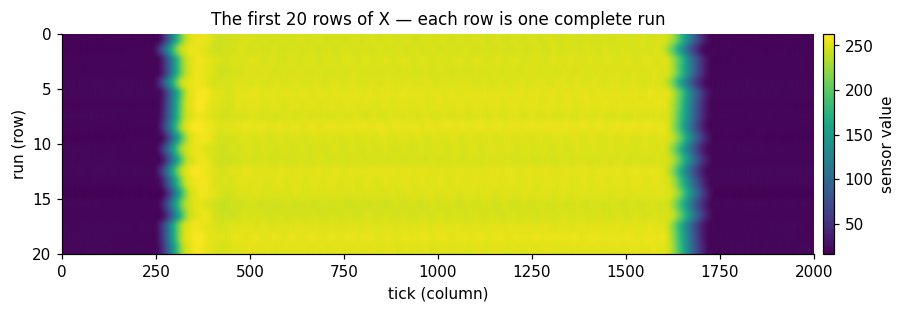

In [6]:
fig, ax = plt.subplots(figsize=(10.5, 2.6))
im = ax.imshow(X[:20], aspect="auto", cmap="viridis",
               extent=(0, N_TICKS, 20, 0))
ax.set_xlabel("tick (column)")
ax.set_ylabel("run (row)")
ax.set_title("The first 20 rows of X — each row is one complete run")
fig.colorbar(im, ax=ax, label="sensor value", pad=0.01)
plt.show()

### One hundred healthy runs  <span style="color:#888">(slide 10)</span>

Ten of them drawn on top of each other. At full scale they look like one
trace. The differences live in the zoom.

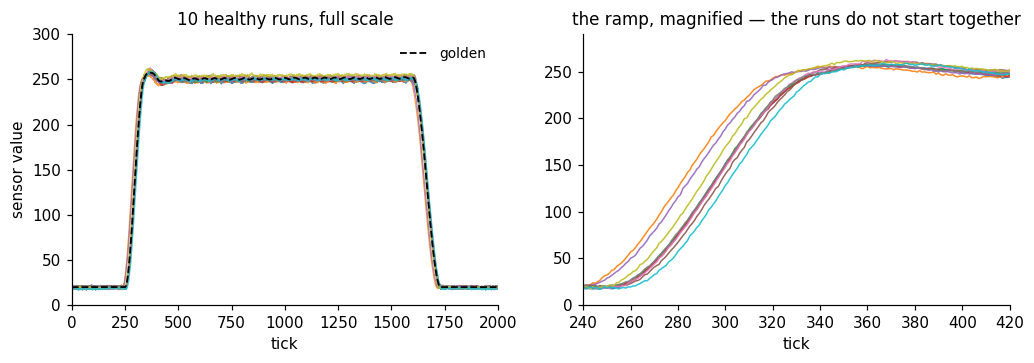

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(11.0, 3.2))
for y in X[:10]:
    axes[0].plot(t, y, lw=0.8, alpha=0.8)
    axes[1].plot(t, y, lw=1.0, alpha=0.9)
axes[0].plot(t, golden, color="k", lw=1.2, ls="--", label="golden")
axes[0].set_xlim(0, N_TICKS); axes[0].set_ylim(0, 300)
axes[0].set_title("10 healthy runs, full scale")
axes[0].set_xlabel("tick"); axes[0].set_ylabel("sensor value")
axes[0].legend(frameon=False, fontsize=9)
axes[1].set_xlim(240, 420); axes[1].set_ylim(0, 290)
axes[1].set_title("the ramp, magnified — the runs do not start together")
axes[1].set_xlabel("tick")
plt.show()

---
## 4 · The five knobs  <span style="color:#888">(slides 11–12)</span>

Because we generated the data, we know exactly what varied. Collect the knob
settings into arrays and look at their spread. These are the numbers PCA will
have to rediscover later, without being told.

In [8]:
knobs = {
    "time shift (ticks)":   np.array([m["shift"] for m in META]),
    "gain (×)":             np.array([m["gain"] for m in META]),
    "offset (units)":       np.array([m["offset"] for m in META]),
    "ripple amp (units)":   np.array([m["ripple_amp"] for m in META]),
    "ripple period (ticks)": np.array([m["ripple_period"] for m in META]),
    "overshoot frac":       np.array([m["overshoot_frac"] for m in META]),
    "plateau drift (units)": np.array([m["drift_total"] for m in META]),
}

shift = knobs["time shift (ticks)"]      # used repeatedly below

print(f"{'knob':<24}{'mean':>10}{'sigma':>10}{'min':>10}{'max':>10}")
for name, v in knobs.items():
    print(f"{name:<24}{v.mean():>10.3f}{v.std(ddof=1):>10.3f}{v.min():>10.3f}{v.max():>10.3f}")

knob                          mean     sigma       min       max
time shift (ticks)          -1.024     6.353   -15.000    15.000
gain (×)                     1.001     0.010     0.976     1.024
offset (units)              -0.117     0.876    -2.724     2.079
ripple amp (units)           0.930     0.158     0.629     1.298
ripple period (ticks)       47.148     1.795    42.171    50.909
overshoot frac               0.060     0.007     0.044     0.076
plateau drift (units)        1.619     0.432     0.240     2.607


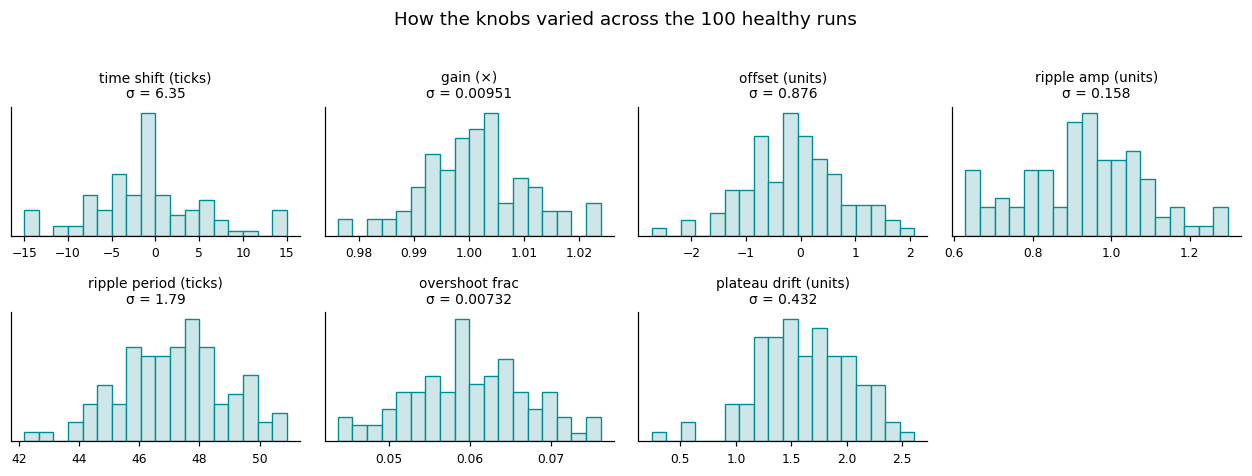

In [9]:
fig, axes = plt.subplots(2, 4, figsize=(11.5, 4.2))
for ax, (name, v) in zip(axes.ravel(), knobs.items()):
    ax.hist(v, bins=18, color=FILL, edgecolor=TEAL, lw=0.9)
    ax.set_title(f"{name}\nσ = {v.std(ddof=1):.3g}", fontsize=9)
    ax.tick_params(labelsize=8)
    ax.set_yticks([])
axes.ravel()[-1].axis("off")
fig.suptitle("How the knobs varied across the 100 healthy runs", y=1.02)
fig.tight_layout()
plt.show()

### Where the variation sits in the trace  <span style="color:#888">(slide 12)</span>

Each knob shows up in a different part of the run. Overlay all 100 runs and
mark the regions: the ramp edge moves with the time shift, the idle level
moves with the offset, the plateau level moves with gain and offset together,
and the plateau texture moves with the ripple and drift jitter.

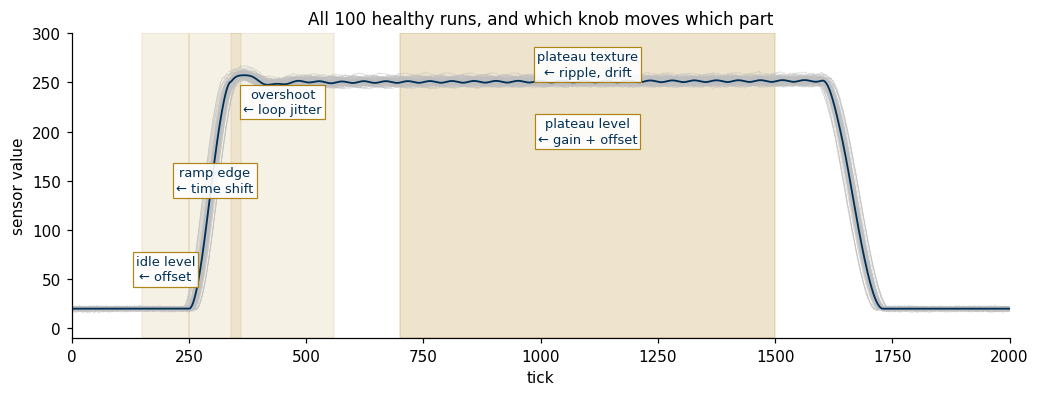

In [10]:
fig, ax = plt.subplots(figsize=(11.0, 3.6))
for y in X:
    ax.plot(t, y, lw=0.4, color="0.75", alpha=0.6)
ax.plot(t, golden, color=NAVY, lw=1.2)

regions = [(150, 250, "idle level\n← offset", 60),
           (250, 360, "ramp edge\n← time shift", 150),
           (340, 560, "overshoot\n← loop jitter", 230),
           (700, 1500, "plateau level\n← gain + offset", 200),
           (700, 1500, "plateau texture\n← ripple, drift", 268)]
for x0, x1, label, ypos in regions:
    ax.axvspan(x0, x1, color=GOLD, alpha=0.10)
    ax.text((x0 + x1) / 2, ypos, label, ha="center", va="center", fontsize=8.5,
            color=NAVY, linespacing=1.25,
            bbox=dict(fc="white", ec=GOLD, lw=0.8, alpha=0.9, pad=2.0))

ax.set_xlim(0, N_TICKS); ax.set_ylim(-10, 300)
ax.set_xlabel("tick"); ax.set_ylabel("sensor value")
ax.set_title("All 100 healthy runs, and which knob moves which part")
plt.show()

---
## 5 · Six fault types  <span style="color:#888">(slide 13)</span>

The faults are injected into runs that already passed the health gate, so a
faulty run differs from a healthy run by the defect and nothing else. Lecture 2
scores all of them; here we only look at what they do to a trace.

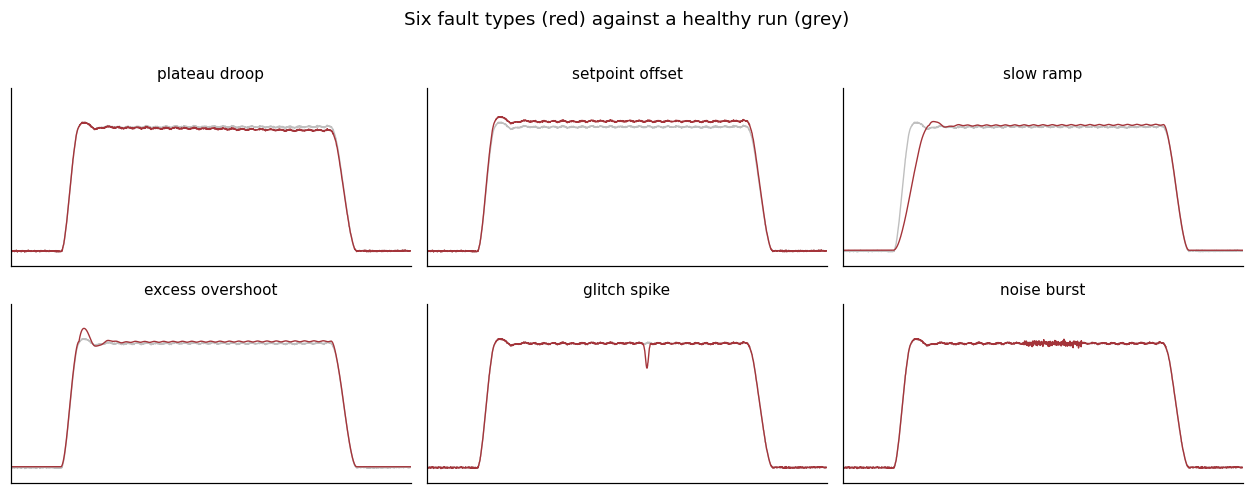

In [11]:
def plateau_envelope(tt, ramp_up_dur=RAMP_UP_DUR):
    up = smoothstep((tt - T_RAMP_UP_START) / ramp_up_dur)
    dn = smoothstep((tt - T_RAMP_DN_START) / RAMP_DN_DUR)
    return up * (1.0 - dn)


SEV = dict(droop=0.030, slow_ramp=2.0, setpoint=0.045, spike=0.20,
           noise=6.0, overshoot=3.2)

base = X[0]                                   # a healthy run to corrupt
env = plateau_envelope(t)
rng_demo = np.random.default_rng(7)

t_os = t - (T_RAMP_UP_START + RAMP_UP_DUR)
prog = np.clip(t_os / (T_RAMP_DN_START - T_RAMP_UP_START - RAMP_UP_DUR), 0, 1)

examples = {}
examples["plateau droop"] = base - env * SEV["droop"] * SPAN * prog
examples["setpoint offset"] = base + env * SEV["setpoint"] * SPAN
examples["slow ramp"] = golden_signal(t, ramp_up_dur=RAMP_UP_DUR * SEV["slow_ramp"])
examples["excess overshoot"] = golden_signal(t, overshoot_frac=OVERSHOOT_FRAC * SEV["overshoot"])
spike = base.copy()
spike += -SEV["spike"] * SPAN * np.exp(-((t - 1100) / 10.0) ** 2)
examples["glitch spike"] = spike
burst = base.copy()
burst[900:1200] += rng_demo.normal(0, NOISE_STD * (SEV["noise"] - 1), 300)
examples["noise burst"] = burst

fig, axes = plt.subplots(2, 3, figsize=(11.5, 4.4))
for ax, (name, y) in zip(axes.ravel(), examples.items()):
    ax.plot(t, base, color="0.75", lw=0.9)
    ax.plot(t, y, color=RED, lw=0.9)
    ax.set_title(name, fontsize=10)
    ax.set_xlim(0, N_TICKS); ax.set_ylim(-10, 320)
    ax.set_xticks([]); ax.set_yticks([])
fig.suptitle("Six fault types (red) against a healthy run (grey)", y=1.01)
fig.tight_layout()
plt.show()

---
## 6 · A run is a vector  <span style="color:#888">(slides 14–16)</span>

Stop thinking of a run as a picture and start thinking of it as a list of
2000 numbers — a single point in 2000-dimensional space. The 100 runs are 100
points. They are not scattered through that space: they sit in a small,
structured region, because they were all made by turning five knobs.

The first two steps of PCA are arithmetic you already know.

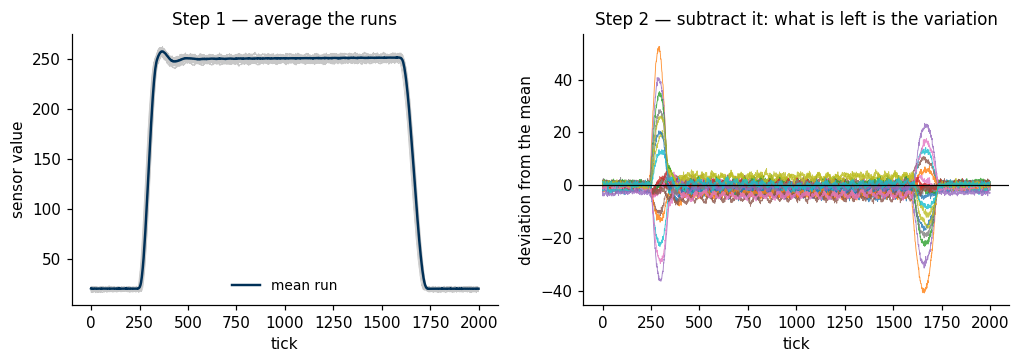

typical run:        178.3 units
typical deviation:  2.61 units
largest deviation:  64.0 units  (on the ramp edge)


In [12]:
mean_run = X.mean(axis=0)
D = X - mean_run                      # deviations: what each run does differently

fig, axes = plt.subplots(1, 2, figsize=(11.0, 3.2))
for y in X[:20]:
    axes[0].plot(t, y, lw=0.5, color="0.78")
axes[0].plot(t, mean_run, color=NAVY, lw=1.6, label="mean run")
axes[0].set_title("Step 1 — average the runs")
axes[0].set_xlabel("tick"); axes[0].set_ylabel("sensor value")
axes[0].legend(frameon=False, fontsize=9)

for d in D[:20]:
    axes[1].plot(t, d, lw=0.6, alpha=0.8)
axes[1].axhline(0, color="k", lw=0.8)
axes[1].set_title("Step 2 — subtract it: what is left is the variation")
axes[1].set_xlabel("tick"); axes[1].set_ylabel("deviation from the mean")
plt.show()

print(f"typical run:        {np.abs(X).mean():.1f} units")
print(f"typical deviation:  {np.abs(D).mean():.2f} units")
print(f"largest deviation:  {np.abs(D).max():.1f} units  (on the ramp edge)")

The deviations are where the information is. The mean run carries the recipe,
which every run shares and which therefore tells you nothing about *this* run.

---
## 7 · Eigentraces  <span style="color:#888">(slides 17–19)</span>

The deviations are not independent. When a run starts late, its whole ramp
edge moves together — 90 samples move as one. PCA finds those shared patterns.

The computation is one SVD. The rows of `Vt` are the **eigentraces**: full
2000-point shapes, ordered by how much of the population's variance each one
explains. `T = D @ P` gives every run's **coefficients** — how much of each
eigentrace that run contains.

The name is a nod to *eigenfaces*: the same construction, applied to faces,
gives a small set of face-shaped images whose weighted sums reproduce any face
in the collection.

In [13]:
def pca_fit(Xgood, k=8):
    """Return the mean, the first k eigentraces (columns of P), and the variances."""
    mu = Xgood.mean(axis=0)
    Z = Xgood - mu
    U, s, Vt = np.linalg.svd(Z, full_matrices=False)
    var = s ** 2 / (Xgood.shape[0] - 1)
    return mu, Vt[:k].T, var


MU, P, VAR = pca_fit(X, k=8)
EVR = VAR / VAR.sum()
T = (X - MU) @ P                       # coefficients: 100 runs x 8 numbers

print("explained variance of the first 8 components (%):")
print(np.round(EVR[:8] * 100, 2))
print(f"\nfirst three together: {EVR[:3].sum():.2%}")

explained variance of the first 8 components (%):
[81.97 13.4   1.53  0.68  0.23  0.17  0.16  0.14]

first three together: 96.90%


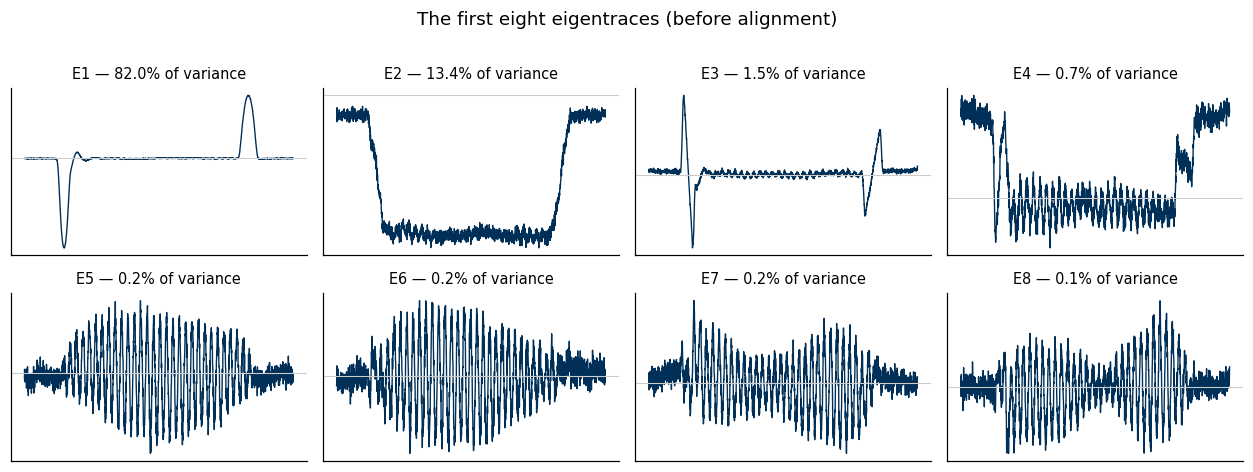

In [14]:
fig, axes = plt.subplots(2, 4, figsize=(11.5, 4.2))
for i, ax in enumerate(axes.ravel()):
    ax.plot(t, P[:, i], color=NAVY, lw=0.9)
    ax.axhline(0, color="0.8", lw=0.7)
    ax.set_title(f"E{i+1} — {EVR[i]*100:.1f}% of variance", fontsize=9.5)
    ax.set_xticks([]); ax.set_yticks([])
fig.suptitle("The first eight eigentraces (before alignment)", y=1.01)
fig.tight_layout()
plt.show()

Read the shapes, not the numbers. E1 is a sharp spike at the ramp edge — a
pattern that is zero everywhere except where the runs disagree about *when*
the step started. That is the time shift, and it dominates.

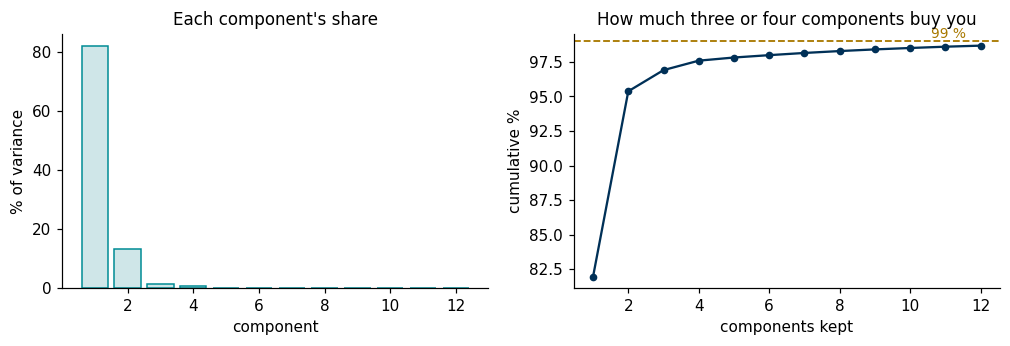

In [15]:
# the variance spectrum, and the cumulative version
fig, axes = plt.subplots(1, 2, figsize=(11.0, 3.0))
axes[0].bar(np.arange(1, 13), EVR[:12] * 100, color=FILL, edgecolor=TEAL)
axes[0].set_xlabel("component"); axes[0].set_ylabel("% of variance")
axes[0].set_title("Each component's share")
axes[1].plot(np.arange(1, 13), np.cumsum(EVR[:12]) * 100, "o-", color=NAVY, ms=4)
axes[1].axhline(99, color=GOLD, ls="--", lw=1.2)
axes[1].text(11.6, 99.2, "99 %", color=GOLD, ha="right", fontsize=9)
axes[1].set_xlabel("components kept"); axes[1].set_ylabel("cumulative %")
axes[1].set_title("How much three or four components buy you")
plt.show()

### Rebuilding a run from a few numbers  <span style="color:#888">(slides 18–19)</span>

The reconstruction is

$$\hat{x} \;=\; \text{mean} \;+\; t_1 E_1 + t_2 E_2 + \dots + t_k E_k$$

Three numbers, three fixed shapes, one 2000-point trace back out. Watch what
each extra component adds.

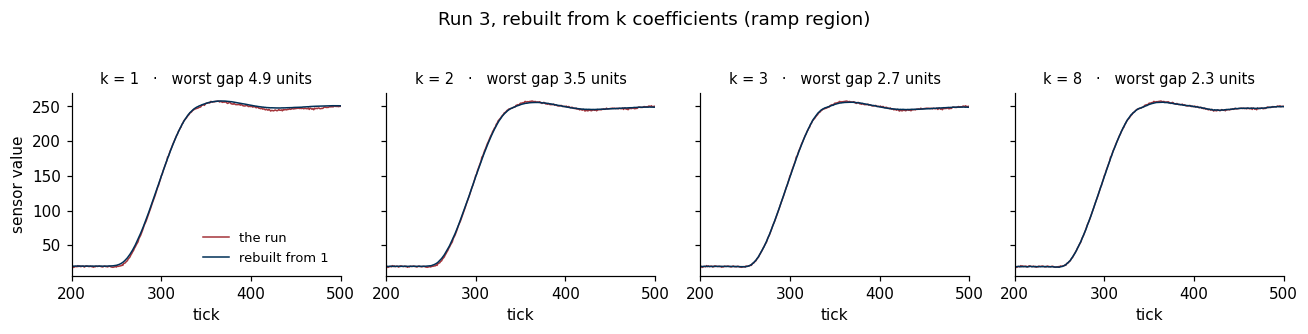

In [16]:
run_id = 3
fig, axes = plt.subplots(1, 4, figsize=(12.0, 2.9), sharey=True)
for ax, k in zip(axes, [1, 2, 3, 8]):
    approx = MU + T[run_id, :k] @ P[:, :k].T
    err = np.abs(X[run_id] - approx).max()
    ax.plot(t, X[run_id], color=RED, lw=1.0, label="the run")
    ax.plot(t, approx, color=NAVY, lw=1.0, label=f"rebuilt from {k}")
    ax.set_title(f"k = {k}   ·   worst gap {err:.1f} units", fontsize=9.5)
    ax.set_xlim(200, 500)
    ax.set_xlabel("tick")
axes[0].set_ylabel("sensor value")
axes[0].legend(frameon=False, fontsize=8.5, loc="lower right")
fig.suptitle(f"Run {run_id}, rebuilt from k coefficients (ramp region)", y=1.03)
fig.tight_layout()
plt.show()

---
## 8 · What the eigentraces mean  <span style="color:#888">(slides 20–23)</span>

An eigentrace is a direction. To find out what a direction *does*, walk along
it: take the mean run and add ±2σ of one component at a time.

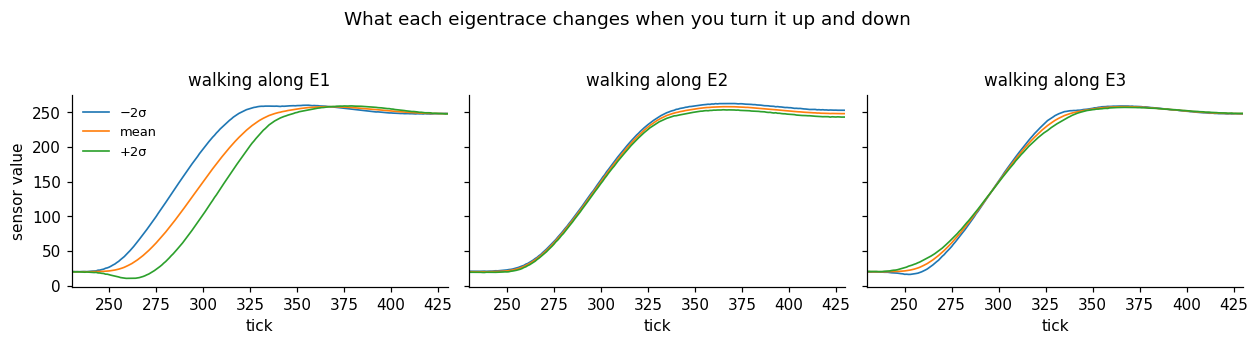

In [17]:
sd = T.std(axis=0, ddof=1)
fig, axes = plt.subplots(1, 3, figsize=(11.5, 3.0), sharey=True)
for j, ax in enumerate(axes):
    for c, lab in [(-2, "−2σ"), (0, "mean"), (2, "+2σ")]:
        y = MU + c * sd[j] * P[:, j]
        ax.plot(t, y, lw=1.1, label=lab)
    ax.set_xlim(230, 430)
    ax.set_title(f"walking along E{j+1}")
    ax.set_xlabel("tick")
axes[0].set_ylabel("sensor value")
axes[0].legend(frameon=False, fontsize=8.5)
fig.suptitle("What each eigentrace changes when you turn it up and down", y=1.03)
fig.tight_layout()
plt.show()

### Which knobs did PCA recover?  <span style="color:#888">(slides 22–23)</span>

This is the honest test. PCA was never told about shifts or gains. If a
component tracks a knob, the correlation between that component's coefficient
and the knob's value across the 100 runs will be near ±1.

We also measure four *derived* quantities straight off each trace — the idle
level, the plateau level, the ramp slope, the ripple amplitude — because those
are what an engineer would actually name.

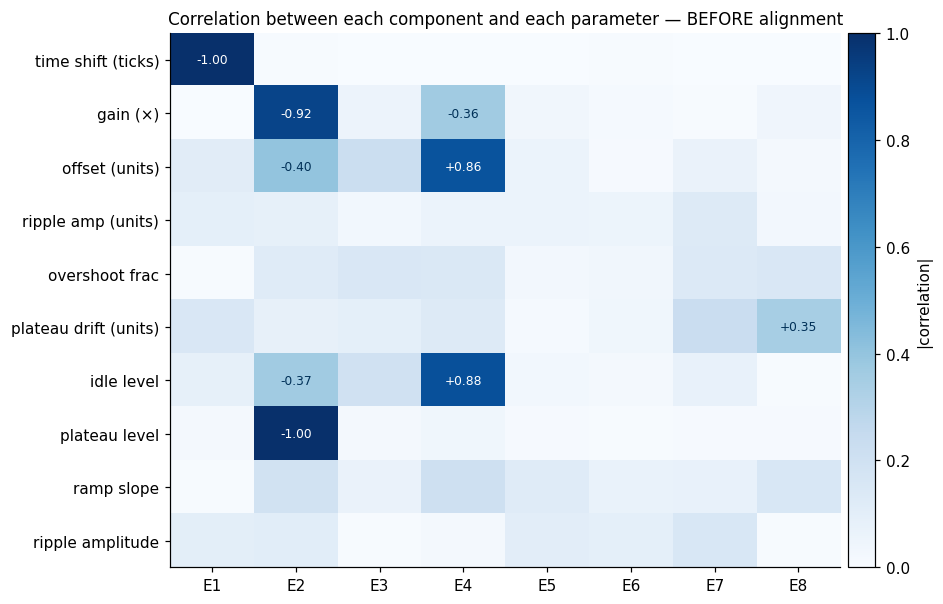

In [18]:
def trace_stats(Xm):
    """Physical measurements taken directly from each trace."""
    idle = Xm[:, 50:200].mean(axis=1)
    plat = Xm[:, 800:1500].mean(axis=1)
    slope = np.abs(np.diff(Xm[:, 240:400], axis=1)).max(axis=1)
    # de-trend the plateau before measuring ripple, and trim the convolution edges
    ker = np.ones(81) / 81
    sm = np.apply_along_axis(lambda r: np.convolve(r, ker, mode="same"), 1,
                             Xm[:, 800:1500])
    ripple = (Xm[:, 800:1500] - sm)[:, 45:-45].std(axis=1)
    return {"idle level": idle, "plateau level": plat,
            "ramp slope": slope, "ripple amplitude": ripple}


def correlation_table(T, extra):
    """|corr| between every component and every parameter, as a labelled matrix."""
    names = list(extra.keys())
    M = np.zeros((len(names), T.shape[1]))
    for i, nm in enumerate(names):
        for j in range(T.shape[1]):
            M[i, j] = np.corrcoef(extra[nm], T[:, j])[0, 1]
    return names, M


params = dict(knobs)
params.pop("ripple period (ticks)")           # jitter too small to be recoverable
params.update(trace_stats(X))
names, C = correlation_table(T, params)


def show_corr(names, C, title):
    fig, ax = plt.subplots(figsize=(9.0, 0.42 * len(names) + 1.4))
    im = ax.imshow(np.abs(C), cmap="Blues", vmin=0, vmax=1, aspect="auto")
    ax.set_xticks(range(C.shape[1]))
    ax.set_xticklabels([f"E{j+1}" for j in range(C.shape[1])])
    ax.set_yticks(range(len(names)))
    ax.set_yticklabels(names)
    for i in range(C.shape[0]):
        for j in range(C.shape[1]):
            v = C[i, j]
            if abs(v) >= 0.30:
                ax.text(j, i, f"{v:+.2f}", ha="center", va="center", fontsize=8,
                        color="white" if abs(v) > 0.6 else NAVY)
    ax.set_title(title)
    fig.colorbar(im, ax=ax, label="|correlation|", pad=0.01)
    fig.tight_layout()
    plt.show()


show_corr(names, C, "Correlation between each component and each parameter — BEFORE alignment")

In [19]:
# the strongest match for every parameter, in one table
print(f"{'parameter':<24}{'best component':>16}{'corr':>9}")
for i, nm in enumerate(names):
    j = int(np.argmax(np.abs(C[i])))
    print(f"{nm:<24}{'E'+str(j+1):>16}{C[i, j]:>9.3f}")

parameter                 best component     corr
time shift (ticks)                    E1   -1.000
gain (×)                              E2   -0.920
offset (units)                        E4    0.864
ripple amp (units)                    E7    0.129
overshoot frac                        E8   -0.151
plateau drift (units)                 E8    0.347
idle level                            E4    0.878
plateau level                         E2   -0.998
ramp slope                            E4    0.205
ripple amplitude                      E7    0.155


Read the table. Before alignment, **the time shift owns the first component**,
and it owns it almost perfectly. The knobs an engineer cares about — gain,
offset, plateau level — are pushed into later components or split across
several. The largest source of variance in the population is a quantity that
says nothing about process health.

---
## 9 · How many numbers does a run need?  <span style="color:#888">(slide 24)</span>

Reconstruct every run from k components and measure the error. Then do the
same for two things that are *not* runs: a square pulse, and pure noise. The
gap between those two curves is the whole idea of the next lecture.

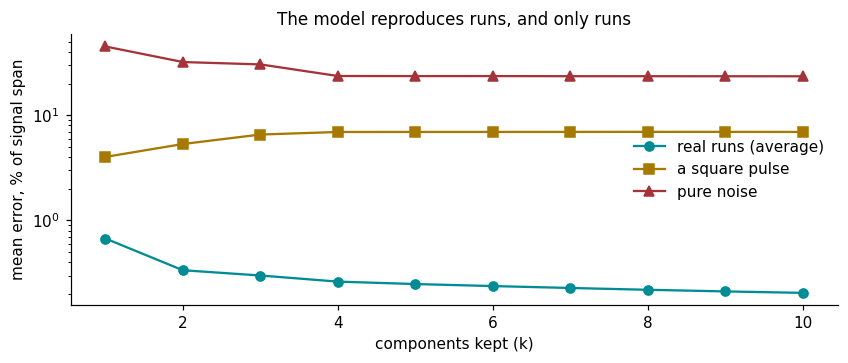

k = 3:   a training run 0.30%   a square pulse 6.6%   pure noise 30.4%
k = 3:   a held-out healthy run 0.34%


In [20]:
def err_pct(a, b, scale=None):
    """Mean absolute error, as a percentage of the healthy signal span.

    This is the error measure used on slide 24: it answers 'how far off is the
    rebuild, compared with how large the signal is', in units anyone can read.
    """
    scale = (X.max() - X.min()) if scale is None else scale
    return 100 * np.abs(a - b).mean() / scale


def rebuild(x, mu, P, k):
    tt = (x - mu) @ P[:, :k]
    return mu + tt @ P[:, :k].T


# the model was fitted with k=8 above; refit keeping more components so we can
# sweep k properly
MU_full, P_full, VAR_full = pca_fit(X, k=20)

ks = np.arange(1, 11)
err_runs = [np.mean([err_pct(x, rebuild(x, MU_full, P_full, k)) for x in X])
            for k in ks]

rng_b = np.random.default_rng(3)
square = np.where((t > 250) & (t < 1700), 250.0, 20.0)
noise = 20 + 230 * rng_b.random(N_TICKS)
err_square = [err_pct(square, rebuild(square, MU_full, P_full, k)) for k in ks]
err_noise = [err_pct(noise, rebuild(noise, MU_full, P_full, k)) for k in ks]

fig, ax = plt.subplots(figsize=(9.0, 3.2))
ax.plot(ks, err_runs, "o-", color=TEAL, label="real runs (average)")
ax.plot(ks, err_square, "s-", color=GOLD, label="a square pulse")
ax.plot(ks, err_noise, "^-", color=RED, label="pure noise")
ax.set_yscale("log")
ax.set_xlabel("components kept (k)")
ax.set_ylabel("mean error, % of signal span")
ax.set_title("The model reproduces runs, and only runs")
ax.legend(frameon=False)
plt.show()

print(f"k = 3:   a training run {err_runs[2]:.2f}%   "
      f"a square pulse {err_square[2]:.1f}%   pure noise {err_noise[2]:.1f}%")

# a held-out healthy run: same generator and seed, but never fitted
X_more, _ = generate_dataset(n_runs=110)
held = X_more[105]
print(f"k = 3:   a held-out healthy run {err_pct(held, rebuild(held, MU_full, P_full, 3)):.2f}%")

Three components rebuild a healthy run to a fraction of a percent, and a
held-out run — one the model never saw — is reproduced just as well. Feed the
same model a square pulse or pure noise and the error is one to two orders of
magnitude larger.

That gap is a detector waiting to be used. The leftover error has a name,
**squared prediction error (SPE)**, and Lecture 2 turns it into half of the
detector.

---
## 10 · Two detectors, and why both fail  <span style="color:#888">(slides 25–27)</span>

Now build the two detectors any engineer would reach for first, and run them
on the hundred healthy runs.

* **Detector 1** — subtract the reference trace and threshold the largest gap.
* **Detector 2** — run PCA on the runs and look for outliers along PC1.

Remember the target: the setpoint fault from section 2 moves the plateau by
about 10 units. A useful detector has to notice 10 units.

DETECTOR 1, on the 100 healthy runs
  runs whose peak residual exceeds 20 units : 38 of 100
  mean peak residual                        : 20 units
  largest residual anywhere                 : 60 units
  largest residual on the plateau           : 10 units


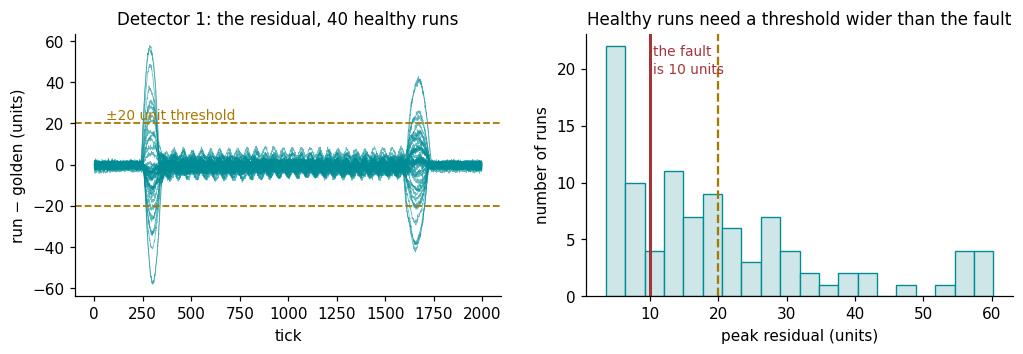

In [21]:
resid = X - golden                       # detector 1: distance from the reference
peak = np.abs(resid).max(axis=1)

print("DETECTOR 1, on the 100 healthy runs")
print(f"  runs whose peak residual exceeds 20 units : {(peak > 20).sum()} of 100")
print(f"  mean peak residual                        : {peak.mean():.0f} units")
print(f"  largest residual anywhere                 : {np.abs(resid).max():.0f} units")
print(f"  largest residual on the plateau           : "
      f"{np.abs(resid[:, 800:1500]).max():.0f} units")

fig, axes = plt.subplots(1, 2, figsize=(11.0, 3.1))
for r in resid[:40]:
    axes[0].plot(t, r, lw=0.5, color=TEAL, alpha=0.6)
axes[0].axhline(20, color=GOLD, ls="--", lw=1.2)
axes[0].axhline(-20, color=GOLD, ls="--", lw=1.2)
axes[0].text(60, 22, "±20 unit threshold", color=GOLD, fontsize=9)
axes[0].set_xlabel("tick"); axes[0].set_ylabel("run − golden (units)")
axes[0].set_title("Detector 1: the residual, 40 healthy runs")

axes[1].hist(peak, bins=20, color=FILL, edgecolor=TEAL, lw=0.9)
axes[1].axvline(20, color=GOLD, ls="--", lw=1.5)
axes[1].axvline(10, color=RED, lw=2.0)
axes[1].text(10.5, axes[1].get_ylim()[1] * 0.85, "the fault\nis 10 units",
             color=RED, fontsize=9, linespacing=1.3)
axes[1].set_xlabel("peak residual (units)"); axes[1].set_ylabel("number of runs")
axes[1].set_title("Healthy runs need a threshold wider than the fault")
plt.show()

The residual has two lobes, and they sit exactly on the two ramps. The reason
is calculus: a run that starts δ ticks late is, to first order,

$$y(t+\delta) \;\approx\; y(t) + \delta\, y'(t)$$

so the residual is the *derivative* of the golden trace, scaled by the shift.
On the plateau the derivative is near zero and a few ticks cost nothing. On
the ramp it reaches close to four units per tick, so six ticks of shift
produce more than twenty units of residual.

To stop the ramps tripping you must set the threshold above 20 units — twice
the size of the fault you are trying to catch.

DETECTOR 2, same 100 runs
  PC1 carries                    : 82.0% of the variance
  total variance in the runs     : 57,857
  spread along PC1               : ±549 units
  corr(PC1, start-time knob)     : -0.9998


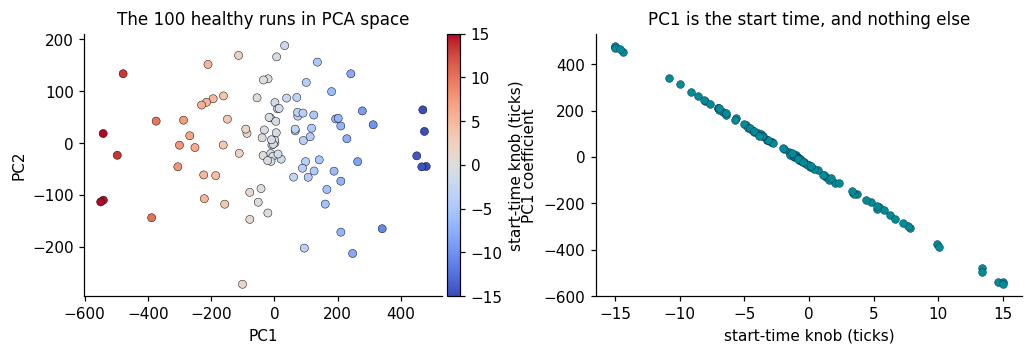

In [22]:
# detector 2: PCA on the raw runs, and what PC1 turns out to be.
# `shift` is the start-time knob the generator drew for each run.

print("DETECTOR 2, same 100 runs")
print(f"  PC1 carries                    : {EVR[0]:.1%} of the variance")
print(f"  total variance in the runs     : {VAR.sum():,.0f}")
print(f"  spread along PC1               : ±{np.abs(T[:, 0]).max():.0f} units")
print(f"  corr(PC1, start-time knob)     : {np.corrcoef(T[:, 0], shift)[0,1]:+.4f}")

fig, axes = plt.subplots(1, 2, figsize=(11.0, 3.1))
sc = axes[0].scatter(T[:, 0], T[:, 1], c=shift, cmap="coolwarm", s=28,
                     edgecolor="k", lw=0.3)
axes[0].set_xlabel("PC1"); axes[0].set_ylabel("PC2")
axes[0].set_title("The 100 healthy runs in PCA space")
fig.colorbar(sc, ax=axes[0], label="start-time knob (ticks)", pad=0.01)

axes[1].scatter(shift, T[:, 0], s=26, color=TEAL, edgecolor=NAVY, lw=0.3)
axes[1].set_xlabel("start-time knob (ticks)"); axes[1].set_ylabel("PC1 coefficient")
axes[1].set_title("PC1 is the start time, and nothing else")
plt.show()

Both detectors fail, and they fail for the same reason. The largest number in
this dataset is *when the run started* — a quantity with no bearing on wafer
quality. Detector 1 spends its threshold on it; detector 2 spends its first
and largest component on it.

PCA never saw the golden trace, yet PC1 came out as a scaled copy of its
derivative. Check that directly:

cosine similarity between E1 and the derivative of the golden trace: 0.995
peak slope of the golden trace: 3.8 units per tick


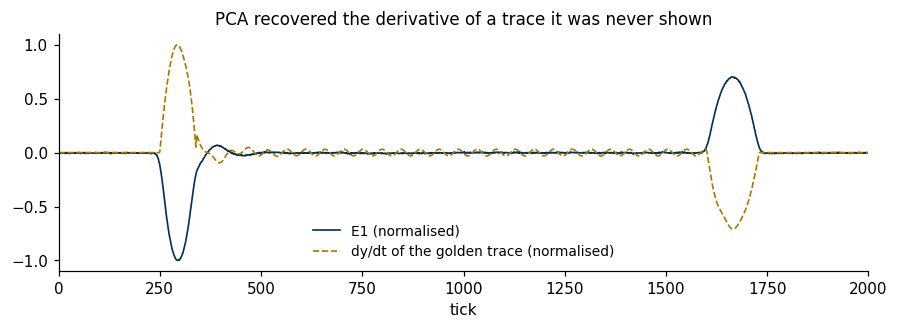

In [23]:
dgolden = np.gradient(golden)
cos_sim = abs(float(P[:, 0] @ dgolden / (np.linalg.norm(P[:, 0]) * np.linalg.norm(dgolden))))
print(f"cosine similarity between E1 and the derivative of the golden trace: {cos_sim:.3f}")
print(f"peak slope of the golden trace: {np.abs(dgolden).max():.1f} units per tick")

fig, ax = plt.subplots(figsize=(9.5, 2.8))
ax.plot(t, P[:, 0] / np.abs(P[:, 0]).max(), color=NAVY, lw=1.1, label="E1 (normalised)")
ax.plot(t, dgolden / np.abs(dgolden).max(), color=GOLD, lw=1.1, ls="--",
        label="dy/dt of the golden trace (normalised)")
ax.set_xlim(0, N_TICKS); ax.set_xlabel("tick")
ax.set_title("PCA recovered the derivative of a trace it was never shown")
ax.legend(frameon=False, fontsize=9)
plt.show()

---
## 11 · Landmark alignment  <span style="color:#888">(slides 28–30)</span>

Four standard options for the start-time problem:

1. **Do nothing** and let the detector waste its dynamic range — what we just saw.
2. **Landmark alignment** — find one repeatable event in every run and line it up.
3. **Dynamic time warping** — stretch time non-uniformly to match a reference.
4. **Indicator-variable alignment** — re-index by a process variable instead of by time.

We use landmark alignment, because the recipe gives us an obvious landmark:
the ramp crosses 50 % of its own span exactly once, and that crossing is where
the step actually began.

The implementation smooths first (so noise cannot move the crossing), then
interpolates between the bracketing samples to get **sub-tick** resolution —
which matters, because the shifts are only a few ticks wide.

estimated shift vs the true knob : corr = 0.9998
estimation error                 : 0.136 ticks (1σ)
true shifts ranged over          : -15.0 .. +15.0 ticks


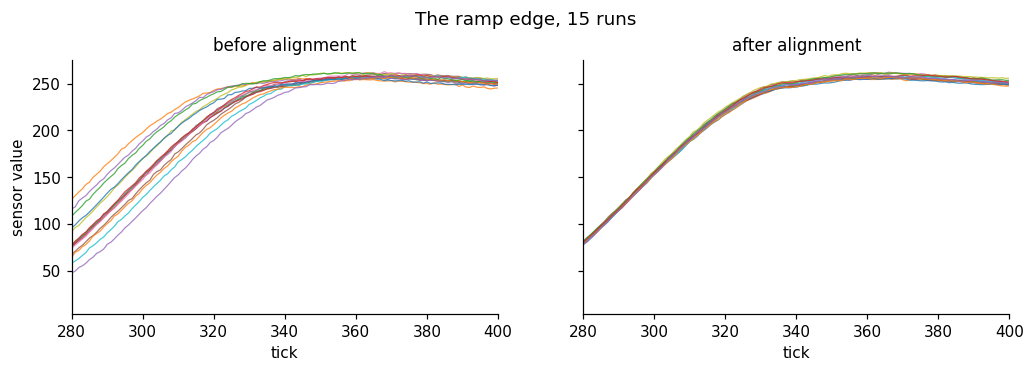

In [24]:
def landmark(y, frac=0.5, smooth=9):
    """Sub-tick index of the first upward crossing of `frac` of this run's span."""
    k = np.ones(smooth) / smooth
    ys = np.convolve(y, k, mode="same")
    lo = np.median(ys[:150])          # this run's idle level
    hi = np.median(ys[800:1400])      # this run's plateau level
    thr = lo + frac * (hi - lo)
    above = np.flatnonzero(ys > thr)
    if above.size == 0:
        return np.nan
    i = above[0]
    if i == 0:
        return 0.0
    y0, y1 = ys[i - 1], ys[i]
    return (i - 1) + (thr - y0) / (y1 - y0)


def align(Xm, ref=None, frac=0.5):
    """Shift every run so its landmark lands on the reference landmark."""
    tt = np.arange(Xm.shape[1], dtype=float)
    if ref is None:
        ref = landmark(golden_signal(tt), frac=frac)
    est = np.array([landmark(y, frac=frac) for y in Xm])
    out = np.empty_like(Xm)
    for i, y in enumerate(Xm):
        d = est[i] - ref                      # this run is late by d ticks
        out[i] = np.interp(tt + d, tt, y)     # resample d ticks later
    return out, est - ref


Xa, est_shift = align(X)

# Sign convention: the generator builds a run as golden_signal(t + shift), so a
# POSITIVE knob makes the run happen EARLIER, and its landmark moves left. The
# estimate of the knob is therefore minus the measured landmark offset.
est_knob = -est_shift

print(f"estimated shift vs the true knob : corr = "
      f"{np.corrcoef(est_knob, shift)[0, 1]:.4f}")
print(f"estimation error                 : {np.std(est_knob - shift):.3f} ticks (1σ)")
print(f"true shifts ranged over          : {shift.min():+.1f} .. {shift.max():+.1f} ticks")

fig, axes = plt.subplots(1, 2, figsize=(11.0, 3.0), sharey=True)
for y in X[:15]:
    axes[0].plot(t, y, lw=0.8, alpha=0.8)
for y in Xa[:15]:
    axes[1].plot(t, y, lw=0.8, alpha=0.8)
axes[0].set_title("before alignment"); axes[1].set_title("after alignment")
for ax in axes:
    ax.set_xlim(280, 400); ax.set_xlabel("tick")
axes[0].set_ylabel("sensor value")
fig.suptitle("The ramp edge, 15 runs", y=1.03)
plt.show()

---
## 12 · Everything again, after alignment  <span style="color:#888">(slides 31–36)</span>

Re-fit PCA on the aligned runs and repeat every measurement. Nothing else
changes: same runs, same code, same 100 rows.

In [25]:
MUa, Pa, VARa = pca_fit(Xa, k=8)
EVRa = VARa / VARa.sum()
Ta = (Xa - MUa) @ Pa

print("explained variance before alignment (%):", np.round(EVR[:5] * 100, 2))
print("explained variance after  alignment (%):", np.round(EVRa[:5] * 100, 2))

explained variance before alignment (%): [81.97 13.4   1.53  0.68  0.23]
explained variance after  alignment (%): [82.51  4.67  1.22  1.17  1.1 ]


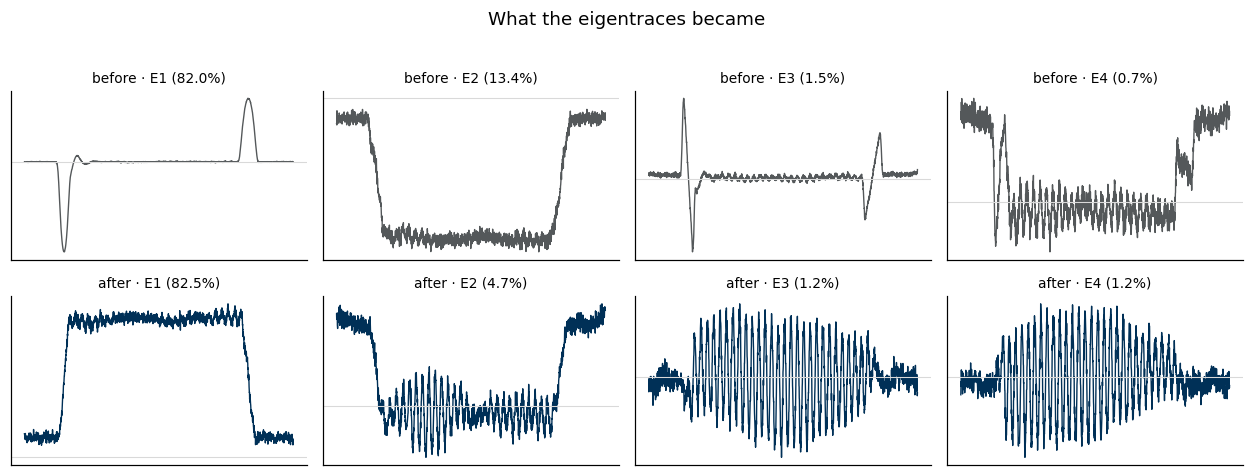

In [26]:
fig, axes = plt.subplots(2, 4, figsize=(11.5, 4.2))
for i in range(4):
    axes[0, i].plot(t, P[:, i], color=GRAY, lw=0.9)
    axes[0, i].set_title(f"before · E{i+1} ({EVR[i]*100:.1f}%)", fontsize=9)
    axes[1, i].plot(t, Pa[:, i], color=NAVY, lw=0.9)
    axes[1, i].set_title(f"after · E{i+1} ({EVRa[i]*100:.1f}%)", fontsize=9)
for ax in axes.ravel():
    ax.axhline(0, color="0.85", lw=0.7)
    ax.set_xticks([]); ax.set_yticks([])
fig.suptitle("What the eigentraces became", y=1.02)
fig.tight_layout()
plt.show()

The sharp ramp-edge spike is gone from E1. What replaces it is a shape that is
flat across the plateau — a level, not an edge.

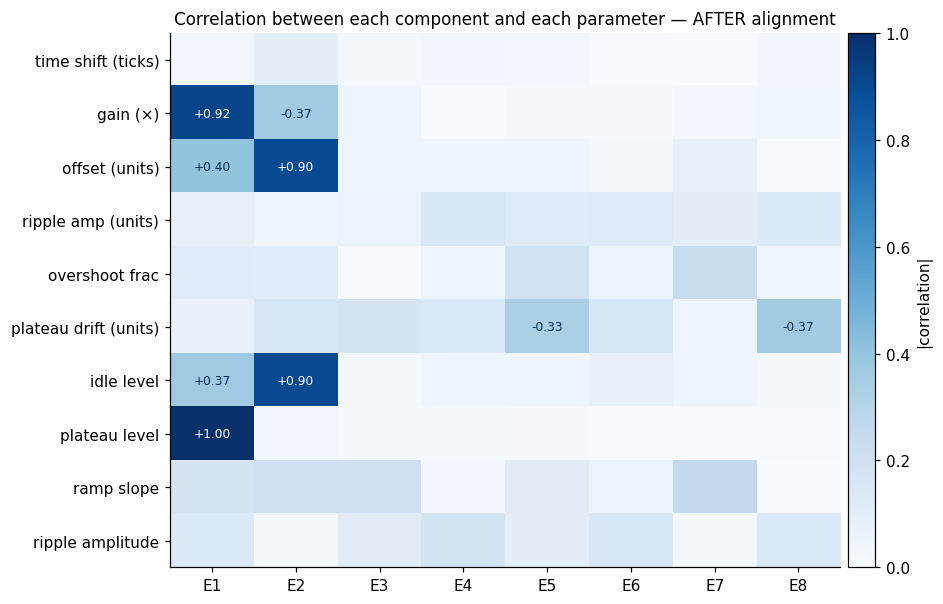

parameter                           before             after
time shift (ticks)              E1 (-1.00)        E2 (+0.09)
gain (×)                        E2 (-0.92)        E1 (+0.92)
offset (units)                  E4 (+0.86)        E2 (+0.90)
ripple amp (units)              E7 (+0.13)        E4 (-0.15)
overshoot frac                  E8 (-0.15)        E7 (-0.23)
plateau drift (units)           E8 (+0.35)        E8 (-0.37)
idle level                      E4 (+0.88)        E2 (+0.90)
plateau level                   E2 (-1.00)        E1 (+1.00)
ramp slope                      E4 (+0.20)        E7 (-0.25)
ripple amplitude                E7 (+0.16)        E4 (-0.18)


In [27]:
params_a = dict(knobs)
params_a.pop("ripple period (ticks)")
params_a.update(trace_stats(Xa))
names_a, Ca = correlation_table(Ta, params_a)
show_corr(names_a, Ca, "Correlation between each component and each parameter — AFTER alignment")

print(f"{'parameter':<24}{'before':>18}{'after':>18}")
for i, nm in enumerate(names_a):
    jb = int(np.argmax(np.abs(C[i])))
    ja = int(np.argmax(np.abs(Ca[i])))
    print(f"{nm:<24}{'E'+str(jb+1)+f' ({C[i, jb]:+.2f})':>18}"
          f"{'E'+str(ja+1)+f' ({Ca[i, ja]:+.2f})':>18}")

This table is the point of the lecture. Before alignment, the components are
organised around a nuisance parameter. After alignment, they are organised
around quantities a process engineer would name: the plateau level, the idle
level, the plateau texture.

### The detectors, after alignment  <span style="color:#888">(slides 31–32)</span>

Same two detectors, same code, aligned runs.

DETECTOR 1                              before       after
  runs above ±20 units, of 100              38           0
  mean peak residual (units)                20           5
  largest residual anywhere                 60          10

DETECTOR 2                              before       after
  total variance                        57,857       9,491
  PC1 share of variance                 82.0%       82.5%
  spread along PC1 (units)                 549         272
  |corr(PC1, start-time knob)|           1.000       0.024


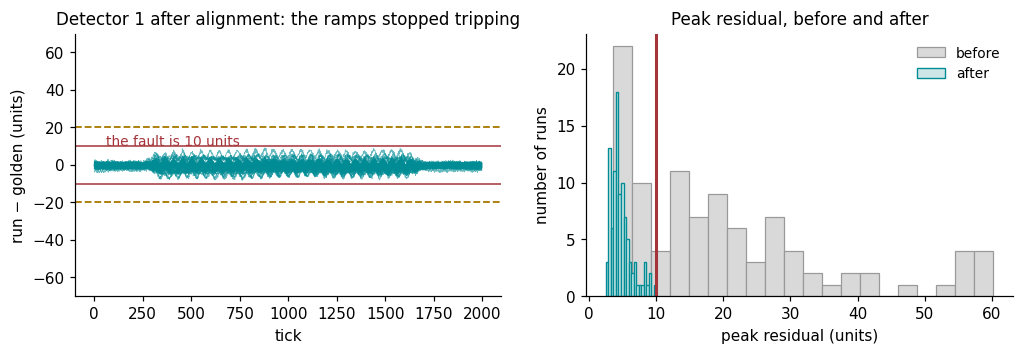

In [28]:
resid_a = Xa - golden
peak_a = np.abs(resid_a).max(axis=1)

print(f"{'DETECTOR 1':<34}{'before':>12}{'after':>12}")
print(f"{'  runs above ±20 units, of 100':<34}{(peak > 20).sum():>12}{(peak_a > 20).sum():>12}")
print(f"{'  mean peak residual (units)':<34}{peak.mean():>12.0f}{peak_a.mean():>12.0f}")
print(f"{'  largest residual anywhere':<34}{np.abs(resid).max():>12.0f}{np.abs(resid_a).max():>12.0f}")

print(f"\n{'DETECTOR 2':<34}{'before':>12}{'after':>12}")
print(f"{'  total variance':<34}{VAR.sum():>12,.0f}{VARa.sum():>12,.0f}")
print(f"{'  PC1 share of variance':<34}{EVR[0]:>11.1%}{EVRa[0]:>12.1%}")
print(f"{'  spread along PC1 (units)':<34}{np.abs(T[:, 0]).max():>12.0f}"
      f"{np.abs(Ta[:, 0]).max():>12.0f}")
print(f"{'  |corr(PC1, start-time knob)|':<34}"
      f"{abs(np.corrcoef(T[:, 0], shift)[0, 1]):>12.3f}"
      f"{abs(np.corrcoef(Ta[:, 0], shift)[0, 1]):>12.3f}")

fig, axes = plt.subplots(1, 2, figsize=(11.0, 3.1))
for r in resid_a[:40]:
    axes[0].plot(t, r, lw=0.5, color=TEAL, alpha=0.6)
axes[0].axhline(20, color=GOLD, ls="--", lw=1.2); axes[0].axhline(-20, color=GOLD, ls="--", lw=1.2)
axes[0].axhline(10, color=RED, lw=1.0); axes[0].axhline(-10, color=RED, lw=1.0)
axes[0].text(60, 10.6, "the fault is 10 units", color=RED, fontsize=9)
axes[0].set_ylim(-70, 70)
axes[0].set_xlabel("tick"); axes[0].set_ylabel("run − golden (units)")
axes[0].set_title("Detector 1 after alignment: the ramps stopped tripping")

axes[1].hist(peak, bins=20, color="0.85", edgecolor="0.6", lw=0.8, label="before")
axes[1].hist(peak_a, bins=20, color=FILL, edgecolor=TEAL, lw=0.9, label="after")
axes[1].axvline(10, color=RED, lw=2.0)
axes[1].set_xlabel("peak residual (units)"); axes[1].set_ylabel("number of runs")
axes[1].set_title("Peak residual, before and after")
axes[1].legend(frameon=False, fontsize=9)
plt.show()

Before alignment the healthy population needed a threshold above 20 units, so
a 10-unit fault could never be caught. After alignment the same population
fits under about 10 units, and a threshold of 8 is defensible. The fault
became detectable without anyone changing the detector — only the data
preparation changed.

Detector 2 tells the same story in a different currency: the total variance in
the population drops by roughly 80 %, and PC1's correlation with the start
time collapses from 1.00 to near zero. The variance that alignment removed was
never process information.

### The same runs, decomposed before and after  <span style="color:#888">(slide 35)</span>

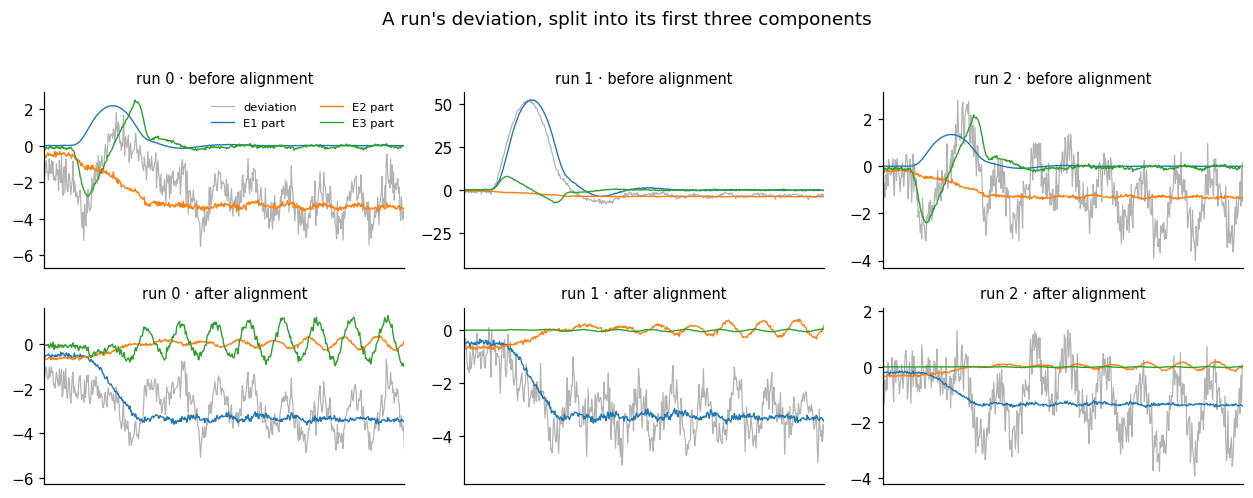

In [29]:
fig, axes = plt.subplots(2, 3, figsize=(11.5, 4.4))
for col, rid in enumerate([0, 1, 2]):
    for row, (Xs, Ms, Ps, Ts, lab) in enumerate([
            (X, MU, P, T, "before"), (Xa, MUa, Pa, Ta, "after")]):
        ax = axes[row, col]
        ax.plot(t, Xs[rid] - Ms, color="0.7", lw=0.8, label="deviation")
        for j in range(3):
            ax.plot(t, Ts[rid, j] * Ps[:, j], lw=0.9, label=f"E{j+1} part")
        ax.set_title(f"run {rid} · {lab} alignment", fontsize=9.5)
        ax.set_xlim(200, 700)
        ax.set_xticks([])
axes[0, 0].legend(frameon=False, fontsize=7.5, ncol=2)
fig.suptitle("A run's deviation, split into its first three components", y=1.02)
fig.tight_layout()
plt.show()

---
## 13 · Summary  <span style="color:#888">(slide 37)</span>

1. A run is a point in 2000-dimensional space. A hundred healthy runs occupy a
   small structured region of it, because they were made by turning a handful
   of knobs.
2. PCA finds that region: a mean run plus a few eigentraces. Three or four
   coefficients reproduce a healthy run to a fraction of a percent.
3. The components are interpretable, but only if the data is prepared properly.
   Fed raw traces, PCA spends its first and largest component on start-time
   misalignment.
4. Landmark alignment removes that nuisance in one pass and hands the
   components back to quantities that mean something physically.
5. Two obvious detectors both failed, and both failed for the same reason.
   Lecture 2 builds the detector that works, and the arithmetic that decides
   whether it is worth switching on.

---
## Exercises

Each one is a small edit to a cell above. The answers are in the last cell of
this notebook — try them first.

**E1.** Re-fit PCA on the aligned runs keeping `k = 1`. How much of the
variance is left unexplained, and which physical quantity did you keep?

**E2.** Change `SHIFT_STD` from 6.0 to 0.5 ticks and regenerate the dataset.
What happens to the first eigentrace *before* alignment, and why?

**E3.** The health gate in `is_healthy` rejects runs whose plateau sits more
than 5 % of span off target. The setpoint fault we inject is 4.5 %. What would
go wrong if the gate were tightened to 2 %?

**E4.** Detector 1 uses `max |run − golden|`. Replace `max` with the mean
absolute deviation over the plateau only. Does the faulty run separate from
the healthy population? Should it?

**E5.** Alignment estimates each run's shift from the 50 % crossing. Change
`frac` to 0.1 and to 0.9 in `align`. Which choice estimates the shift most
accurately, and what does that tell you about where the information is?

In [30]:
# --- Exercise answers ------------------------------------------------------
# Run this cell after you have tried them.

MU1, P1, VAR1 = pca_fit(Xa, k=1)
T1 = (Xa - MU1) @ P1
r_plat = np.corrcoef(T1[:, 0], trace_stats(Xa)["plateau level"])[0, 1]
print("E1  one component explains "
      f"{VAR1[0]/VAR1.sum():.1%} of the variance after alignment; "
      f"it tracks the plateau level at corr = {r_plat:+.2f}.")
print("    The rest is idle level, texture and noise, which one component cannot hold.\n")

print("E2  With SHIFT_STD = 0.5 the ramp-edge spike stops being the largest")
print("    source of variance, so E1 before alignment looks like the E1 you")
print("    otherwise only get after alignment. Alignment and a well-behaved")
print("    tool do the same job.\n")

print("E3  A 2 % gate would reject healthy runs whose plateau happened to sit")
print("    high, and, worse, it would reject the fault itself before it was")
print("    injected — the fault library corrupts runs that already passed the")
print("    gate, so tightening the gate silently changes what a fault is.\n")

rng_f = np.random.default_rng(101)
y_f, _ = make_run(rng_f)
faulty_run = y_f + plateau_envelope(t) * 0.045 * SPAN   # the 10-unit setpoint fault
faulty_aligned = align(faulty_run[None, :])[0][0]
plat_dev = np.abs(Xa[:, 800:1500] - golden[800:1500]).mean(axis=1)
plat_f = np.abs(faulty_aligned[800:1500] - golden[800:1500]).mean()
print(f"E4  plateau-only score: healthy {plat_dev.min():.1f}–{plat_dev.max():.1f}, "
      f"faulty {plat_f:.1f} — it separates cleanly.")
print("    That is a detector tuned to one fault type. It is blind to a spike,")
print("    a slow ramp or a noise burst, which is why Lecture 2 does not build")
print("    detectors one fault at a time.\n")

for frac in (0.1, 0.5, 0.9):
    _, est = align(X, frac=frac)
    print(f"E5  frac = {frac}: shift estimate error = "
          f"{np.std(-est - shift):.3f} ticks (1σ)")
print("    The steepest part of the edge gives the best estimate, because there")
print("    a small time error produces a large amplitude difference.")

E1  one component explains 82.5% of the variance after alignment; it tracks the plateau level at corr = +1.00.
    The rest is idle level, texture and noise, which one component cannot hold.

E2  With SHIFT_STD = 0.5 the ramp-edge spike stops being the largest
    source of variance, so E1 before alignment looks like the E1 you
    otherwise only get after alignment. Alignment and a well-behaved
    tool do the same job.

E3  A 2 % gate would reject healthy runs whose plateau happened to sit
    high, and, worse, it would reject the fault itself before it was
    injected — the fault library corrupts runs that already passed the
    gate, so tightening the gate silently changes what a fault is.

E4  plateau-only score: healthy 0.5–7.4, faulty 6.4 — it separates cleanly.
    That is a detector tuned to one fault type. It is blind to a spike,
    a slow ramp or a noise burst, which is why Lecture 2 does not build
    detectors one fault at a time.

E5  frac = 0.1: shift estimate error = 